# 1. Exploratory Data Analysis (EDA)
Loading the Kaggle dataset metadata and visualizing the high-resolution product images.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Kaggle's internal path to the dataset
KAGGLE_DIR = "/kaggle/input/fashion-product-images-dataset/fashion-dataset/fashion-dataset"
csv_path = os.path.join(KAGGLE_DIR, "styles.csv")

# Load metadata
df = pd.read_csv(csv_path, on_bad_lines='skip')

print("📊 True HD Dataset Overview:")
print(f"Total items: {len(df)}")
print("\nTop 5 Categories (articleType):")
print(df['articleType'].value_counts().head(5))

# Visualize 4 random HD images
sample_items = df.sample(4)
plt.figure(figsize=(16, 6))

for i, (index, row) in enumerate(sample_items.iterrows()):
    # Kaggle image path
    img_path = os.path.join(KAGGLE_DIR, "images", f"{row['id']}.jpg")
    
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        
        # Display resolution dynamically to prove it's HD
        height, width, channels = img.shape
        title_text = f"{row['articleType']}\n{row['productDisplayName'][:20]}...\n({width}x{height} pixels)"
        
        plt.title(title_text, fontsize=10)
        plt.axis('off')
    else:
        print(f"⚠️ Image missing: {row['id']}.jpg")

plt.tight_layout()
plt.show()

# 2. Dataset Loading & Preprocessing
Building a high-speed, unbiased `tf.data` pipeline for Transfer Learning.

## 2.1 Defining Custom Categories
Filtering the dataset to ensure a balanced distribution across men's and women's fashion, mitigating dataset bias.

In [5]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import os

# 1. Our Custom, Unbiased Roster
TARGET_CATEGORIES = [
    'Tshirts', 'Shirts', 'Tops', 'Kurtas', 'Dresses', 
    'Casual Shoes', 'Heels', 'Handbags', 'Watches', 'Sunglasses'
]

print("🎯 Curated Target Categories:")
for i, cat in enumerate(TARGET_CATEGORIES):
    print(f"{i+1}. {cat}")

# Filter the dataframe to ONLY include rows from our target list
df_filtered = df[df['articleType'].isin(TARGET_CATEGORIES)].copy()

🎯 Curated Target Categories:
1. Tshirts
2. Shirts
3. Tops
4. Kurtas
5. Dresses
6. Casual Shoes
7. Heels
8. Handbags
9. Watches
10. Sunglasses


## 2.2 Splitting Train and Validation Sets
Mapping image paths, encoding string labels into integers, and performing an 80/20 stratified split.

In [6]:
# 2. Add exact file paths and remove missing images
df_filtered['image_path'] = df_filtered['id'].apply(
    lambda x: os.path.join(KAGGLE_DIR, "images", f"{x}.jpg")
)
df_filtered = df_filtered[df_filtered['image_path'].apply(os.path.exists)]

# 3. Convert String labels to Integers
label_encoder = LabelEncoder()
df_filtered['label'] = label_encoder.fit_transform(df_filtered['articleType'])

# Save the class names for the Flask app later
class_names = label_encoder.classes_
np.save('class_names.npy', class_names) 

# 4. Split into Training (80%) and Validation (20%) Sets
train_df, val_df = train_test_split(
    df_filtered, test_size=0.2, random_state=42, stratify=df_filtered['label']
)
print(f"\nTraining images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")


Training images: 19114
Validation images: 4779


## 2.3 Building the tf.data Pipeline
Utilizing CPU multi-threading (`AUTOTUNE`) to pre-fetch, decode, and resize HD images in the background so the GPU never bottlenecks.

In [7]:
# 5. The High-Speed Preprocessing Function
def process_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

# 6. Build the Data Conveyor Belts (tf.data)
BATCH_SIZE = 32

# Training Dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_df['image_path'].values, train_df['label'].values))
train_ds = train_ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Validation Dataset 
val_ds = tf.data.Dataset.from_tensor_slices((val_df['image_path'].values, val_df['label'].values))
val_ds = val_ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\n✅ High-Speed tf.data Pipeline Ready!")


✅ High-Speed tf.data Pipeline Ready!


# 3. Model Building (Transfer Learning)
Downloading the pre-trained MobileNetV2 backbone, freezing its feature-extraction layers, and attaching a custom Dense head for our 10 target clothing categories.

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# 1. Load the Pre-trained Base (The "Body")
# include_top=False means we drop the original 1,000-class ImageNet brain
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# 2. Freeze the Base Model
# This stops the weights from updating so we don't destroy pre-learned features
base_model.trainable = False

# 3. Build our Custom Head (The "Brain")
x = base_model.output

# Pool the 2D feature maps down into a 1D vector
x = GlobalAveragePooling2D()(x) 

# Dropout is a regularization technique. It randomly turns off 20% of 
# neurons during training to prevent the model from memorizing the data (overfitting).
x = Dropout(0.2)(x)             

# 4. Final Classification Layer
# 10 units for our 10 balanced categories! 
# Softmax turns the output into percentages (e.g., 90% Shirt, 10% Tshirt)
predictions = Dense(10, activation='softmax')(x) 

# 5. Combine the body and the brain into a single model
model = Model(inputs=base_model.input, outputs=predictions)

# 6. Compile the Model
# We use sparse_categorical_crossentropy because our labels are integers (0-9)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model Architecture Ready!")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model Architecture Ready!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 4. Model Training & Callbacks
Implementing Early Stopping to prevent overfitting and Model Checkpoint to save the best performing weights during the transfer learning process.

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Setup Callbacks
# Stop training if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

# Save the absolute best version of the model dynamically
checkpoint = ModelCheckpoint(
    'stylevision_v1.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    verbose=1
)

# 2. Train the Model!
EPOCHS = 15

print("🚀 Starting Transfer Learning...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

🚀 Starting Transfer Learning...
Epoch 1/15


I0000 00:00:1771776558.842248     130 service.cc:152] XLA service 0x7878c8212400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771776558.842286     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771776558.842290     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771776559.864258     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-22 16:09:27.599830: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 16:09:27.736946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1771776569.716813     130 device_co

597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.8197 - loss: 0.5235

2026-02-22 16:12:36.251497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 16:12:36.395377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 16:12:36.531997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.8198 - loss: 0.5232

...

598/598 ━━━━━━━━━━━━━━━━━━━━ 161s 245ms/step - accuracy: 0.9297 - loss: 0.1887 - val_accuracy: 0.9358 - val_loss: 0.1716
Epoch 3/15
597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9395 - loss: 0.1621
Epoch 3: val_accuracy improved from 0.93576 to 0.93660, saving model to stylevision_v1.h5


598/598 ━━━━━━━━━━━━━━━━━━━━ 160s 245ms/step - accuracy: 0.9395 - loss: 0.1621 - val_accuracy: 0.9366 - val_loss: 0.1624
Epoch 4/15
597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9444 - loss: 0.1495
Epoch 4: val_accuracy improved from 0.93660 to 0.94204, saving model to stylevision_v1.h5


598/598 ━━━━━━━━━━━━━━━━━━━━ 173s 267ms/step - accuracy: 0.9444 - loss: 0.1495 - val_accuracy: 0.9420 - val_loss: 0.1501
Epoch 5/15
597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9477 - loss: 0.1390
Epoch 5: val_accuracy did not improve from 0.94204
598/598 ━━━━━━━━━━━━━━━━━━━━ 161s 246ms/step - accuracy: 0.9477 - loss: 0.1390 - val_accuracy: 0.9356 - val_loss: 0.1594
Epoch 6/15
597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9507 - loss: 0.1328
Epoch 6: val_accuracy improved from 0.94204 to 0.94476, saving model to stylevision_v1.h5


598/598 ━━━━━━━━━━━━━━━━━━━━ 163s 251ms/step - accuracy: 0.9507 - loss: 0.1328 - val_accuracy: 0.9448 - val_loss: 0.1427
Epoch 7/15
597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9517 - loss: 0.1302
Epoch 7: val_accuracy did not improve from 0.94476
598/598 ━━━━━━━━━━━━━━━━━━━━ 161s 248ms/step - accuracy: 0.9517 - loss: 0.1302 - val_accuracy: 0.9418 - val_loss: 0.1462
Epoch 8/15
597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9534 - loss: 0.1242
Epoch 8: val_accuracy did not improve from 0.94476
598/598 ━━━━━━━━━━━━━━━━━━━━ 159s 244ms/step - accuracy: 0.9534 - loss: 0.1242 - val_accuracy: 0.9418 - val_loss: 0.1533
Epoch 9/15
597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9547 - loss: 0.1201
Epoch 9: val_accuracy improved from 0.94476 to 0.94518, saving model to stylevision_v1.h5


598/598 ━━━━━━━━━━━━━━━━━━━━ 161s 247ms/step - accuracy: 0.9547 - loss: 0.1201 - val_accuracy: 0.9452 - val_loss: 0.1444
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 6.


# 5. Evaluation & Error Analysis
Generating predictions on the validation dataset to compute a Confusion Matrix and identify the model's classification blind spots.

🔍 Running inference on the validation set...


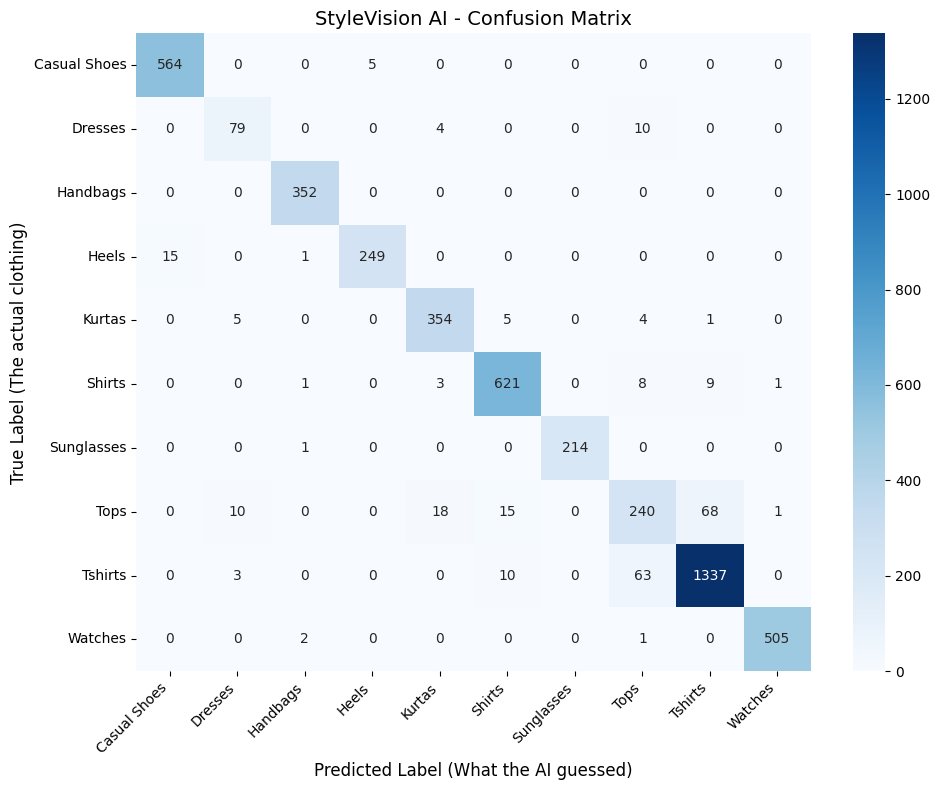


📊 Detailed Classification Report:
              precision    recall  f1-score   support

Casual Shoes       0.97      0.99      0.98       569
     Dresses       0.81      0.85      0.83        93
    Handbags       0.99      1.00      0.99       352
       Heels       0.98      0.94      0.96       265
      Kurtas       0.93      0.96      0.95       369
      Shirts       0.95      0.97      0.96       643
  Sunglasses       1.00      1.00      1.00       215
        Tops       0.74      0.68      0.71       352
     Tshirts       0.94      0.95      0.95      1413
     Watches       1.00      0.99      1.00       508

    accuracy                           0.94      4779
   macro avg       0.93      0.93      0.93      4779
weighted avg       0.94      0.94      0.94      4779



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("🔍 Running inference on the validation set...")

y_true = []
y_pred_probs = []

# Loop through the validation data conveyor belt to get predictions
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    # Verbose=0 hides the progress bar for every single batch
    preds = model.predict(images, verbose=0) 
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
# Convert percentage probabilities into the final class prediction
y_pred = np.argmax(y_pred_probs, axis=1)

# Load the class names we saved earlier
class_names = np.load('class_names.npy', allow_pickle=True)

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Plot it beautifully using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('StyleVision AI - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label (What the AI guessed)', fontsize=12)
plt.ylabel('True Label (The actual clothing)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Print the detailed breakdown
print("\n📊 Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))